<a href="https://colab.research.google.com/github/felicia2025-hue/Zomato-Delivery-Performance/blob/main/Zomato_Delivery_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DATA UNDERSTANDING**

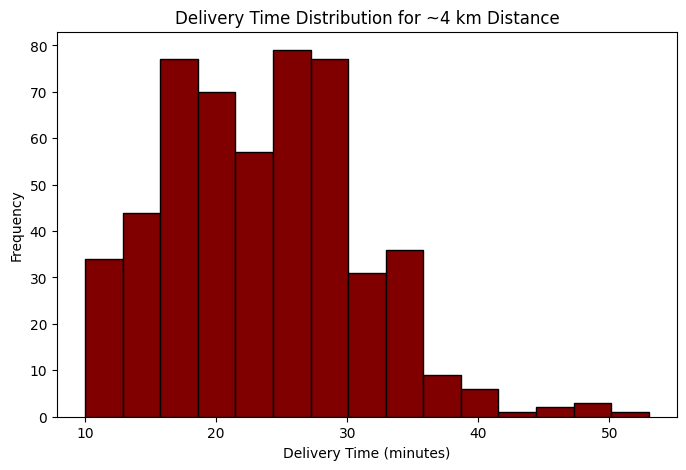

,time_taken_(min)
count,527.000000
mean,23.489564
std,7.407438
min,10.000000
25%,18.000000
50%,24.000000
75%,29.000000
max,53.000000


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
file_path = '/content/Zomato Dataset.csv'
df = pd.read_csv(file_path)

# Clean column names
df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

# Function to calculate distance using the Haversine formula
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of Earth in kilometers
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# Calculate distance between restaurant and delivery location
df['distance_km'] = haversine(df['restaurant_latitude'], df['restaurant_longitude'],
                               df['delivery_location_latitude'], df['delivery_location_longitude'])

# Filter a narrow distance range (e.g., around 4 km ± 0.5 km)
same_distance_df = df[(df['distance_km'] >= 3.5) & (df['distance_km'] <= 4.5)]

# Plot histogram of delivery times for the same distance
plt.figure(figsize=(8, 5))
plt.hist(same_distance_df['time_taken_(min)'], bins=15, color='#800000', edgecolor='black')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')
plt.title('Delivery Time Distribution for ~4 km Distance')
plt.show()

# Summary statistics for this distance range
same_distance_stats = same_distance_df['time_taken_(min)'].describe()
same_distance_stats

In [ ]:
import pandas as pd, csv

# Load the Zomato dataset
path = '/content/Zomato Dataset.csv'
df = pd.read_csv("Zomato Dataset.csv", engine='python', on_bad_lines='skip')

# Get dataset characteristics
num_rows, num_columns = df.shape
column_info = df.dtypes.value_counts()
data_types = df.dtypes

# Create a summary DataFrame
summary = pd.DataFrame({
    "Number of Records": [num_rows],
    "Number of Variables": [num_columns],
    "Numeric Variables": [sum(data_types == 'int64') + sum(data_types == 'float64')],
    "Categorical Variables": [sum(data_types == 'object')]
})

summary, df.head()

(   Number of Records  Number of Variables  Numeric Variables  \
 0              45584                   20                  9   
 
    Categorical Variables  
 0                     11  ,
        ID Delivery_person_ID  Delivery_person_Age  Delivery_person_Ratings  \
 0  0xcdcd      DEHRES17DEL01                 36.0                      4.2   
 1  0xd987      KOCRES16DEL01                 21.0                      4.7   
 2  0x2784     PUNERES13DEL03                 23.0                      4.7   
 3  0xc8b6     LUDHRES15DEL02                 34.0                      4.3   
 4  0xdb64      KNPRES14DEL02                 24.0                      4.7   
 
    Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
 0            30.327968             78.046106                   30.397968   
 1            10.003064             76.307589                   10.043064   
 2            18.562450             73.916619                   18.652450   
 3            30.899584    

# **DATA PREPROCESSING**

## Data Cleaning

***Check Duplicates & Missing Value***

In [ ]:
# Duplicates data
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Missing values
missing_summary = pd.DataFrame({
    "Column Name": df.columns,
    "Missing Values": df.isnull().sum().values
})
print(missing_summary)

Number of duplicate rows: 0
                    Column Name  Missing Values
0                            ID               0
1            Delivery_person_ID               0
2           Delivery_person_Age            1854
3       Delivery_person_Ratings            1908
4           Restaurant_latitude               0
5          Restaurant_longitude               0
6    Delivery_location_latitude               0
7   Delivery_location_longitude               0
8                    Order_Date               0
9                   Time_Orderd            1731
10            Time_Order_picked               0
11           Weather_conditions             616
12         Road_traffic_density             601
13            Vehicle_condition               0
14                Type_of_order               0
15              Type_of_vehicle               0
16          multiple_deliveries             993
17                     Festival             228
18                         City            1200
19          

In [ ]:
# Drop rows with any missing values
df_dropna = df.dropna()

records_after_drop = df_dropna.shape[0]
variables_after_drop = df_dropna.shape[1]
print(f"Number of records after dropna: {records_after_drop}")
print(f"Number of variables: {variables_after_drop}")

missing_after = df_dropna.isnull().sum()
missing_after = missing_after[missing_after > 0]

if missing_after.empty:
    print("\nNo missing values remain after dropna")
else:
    print("\n⚠ Missing values still exist in:")
    print(missing_after)

Number of records after dropna: 41359
Number of variables: 20

No missing values remain after dropna


***Check Invalid Value***

In [ ]:
# INVALID VALUE CHECK

# 1. Delivery_person_Age (unrealistic ages, e.g., < 15 or > 70)
invalid_age = df_dropna[(df_dropna['Delivery_person_Age'] < 15) | (df_dropna['Delivery_person_Age'] > 70)]
print(f"Invalid ages: {len(invalid_age)}")
if not invalid_age.empty:
    print("Unique invalid ages:", invalid_age['Delivery_person_Age'].unique())

# 2. Delivery_person_Ratings (ratings < 0 or > 5)
invalid_ratings = df_dropna[(df_dropna['Delivery_person_Ratings'] < 0) | (df_dropna['Delivery_person_Ratings'] > 5)]
print(f"\nInvalid ratings: {len(invalid_ratings)}")
if not invalid_ratings.empty:
    print("Unique invalid ratings:", invalid_ratings['Delivery_person_Ratings'].unique())

# 3. Time_taken (min) negative values
negative_time = df_dropna[df_dropna['Time_taken (min)'] < 0]
print(f"\nNegative time taken values: {len(negative_time)}")
if not negative_time.empty:
    print("Unique invalid time values:", negative_time['Time_taken (min)'].unique())

# 4. multiple_deliveries negative values
invalid_multiple = df_dropna[df_dropna['multiple_deliveries'] < 0]
print(f"\nInvalid multiple deliveries: {len(invalid_multiple)}")
if not invalid_multiple.empty:
    print("Unique invalid multiple deliveries:", invalid_multiple['multiple_deliveries'].unique())

# 5. Check for invalid categories in categorical columns
categorical_checks = {
    'Weather_conditions': ['Fog', 'Stormy', 'Sunny', 'Sandstorms', 'Windy', 'Cloudy'],
    'Road_traffic_density': ['Low', 'Medium', 'High', 'Jam'],
    'Festival': ['Yes', 'No']
}

print("\nInvalid category values:")
for col, valid_values in categorical_checks.items():
    invalid_values = df_dropna[~df_dropna[col].isin(valid_values)]
    if not invalid_values.empty:
        print(f"- {col}: {invalid_values[col].unique()}")
    else:
        print(f"- {col}: None")

Invalid ages: 0

Invalid ratings: 0

Negative time taken values: 0

Invalid multiple deliveries: 0

Invalid category values:
- Weather_conditions: None
- Road_traffic_density: None
- Festival: None


## Data Manipulation

***Check Data Type***

In [ ]:
# Check the data type of each column
print(df_dropna.dtypes)

# Check some sample values for columns that should be numeric or datetime
check_cols = ['Order_Date', 'Time_Orderd', 'Time_Order_picked',
              'Delivery_person_Age', 'Delivery_person_Ratings',
              'Vehicle_condition', 'multiple_deliveries', 'Time_taken (min)']

for col in check_cols:
    print(f"\n--- {col} ---")
    print(df_dropna[col].head(10))

ID                              object
Delivery_person_ID              object
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weather_conditions              object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries            float64
Festival                        object
City                            object
Time_taken (min)                 int64
dtype: object

--- Order_Date ---
0     12-02-2022
1     13-02-2022
2     04-03-2022
3     13-02-2022
4     14-02-2022
5     02-04-2022
6     01-03-2022
7     16-03-2022
9     15-02-2022
10    16-03-2022
Name: Order_Date

In [ ]:
# Remove leading/trailing spaces from column names
df_dropna.columns = df_dropna.columns.str.strip()

# Standardize column names (if needed)
df_dropna.rename(columns={
    'Order Date': 'Order_Date',
    'Time Orderd': 'Time_Orderd',
    'Time Order picked': 'Time_Order_picked'
}, inplace=True)

# Convert 'Order_Date' column to datetime format
df_dropna['Order_Date'] = pd.to_datetime(df_dropna['Order_Date'], errors='coerce')

# Convert time columns into datetime.time format
df_dropna['Time_Orderd'] = pd.to_datetime(df_dropna['Time_Orderd'], format='%H:%M:%S', errors='coerce').dt.time
df_dropna['Time_Order_picked'] = pd.to_datetime(df_dropna['Time_Order_picked'], format='%H:%M:%S', errors='coerce').dt.time

# Check updated data types
print(df_dropna[['Order_Date', 'Time_Orderd', 'Time_Order_picked']].dtypes)


Order_Date           datetime64[ns]
Time_Orderd          datetime64[ns]
Time_Order_picked    datetime64[ns]
dtype: object


/tmp/ipython-input-54308788.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dropna.rename(columns={
/tmp/ipython-input-54308788.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dropna['Order_Date'] = pd.to_datetime(df_dropna['Order_Date'], errors='coerce')
/tmp/ipython-input-54308788.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#return

# EXPLORATORY DATA ANALYSIS

In [ ]:
# Distance
df_dropna['distance_km'] = haversine(
    df_dropna['Restaurant_latitude'],
    df_dropna['Restaurant_longitude'],
    df_dropna['Delivery_location_latitude'],
    df_dropna['Delivery_location_longitude']
)

# Mode
distance_mode = df_dropna['distance_km'].round(1).mode()[0]
print(f"Most frequent delivery distance (approx.): {distance_mode} km")


Most frequent delivery distance (approx.): 1.5 km


/tmp/ipython-input-567495456.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dropna['distance_km'] = haversine(


Target distance ≈ 1.5 km | Window: [1.0, 2.0] km
Rows in window: 3677 (8.92% of filtered data)


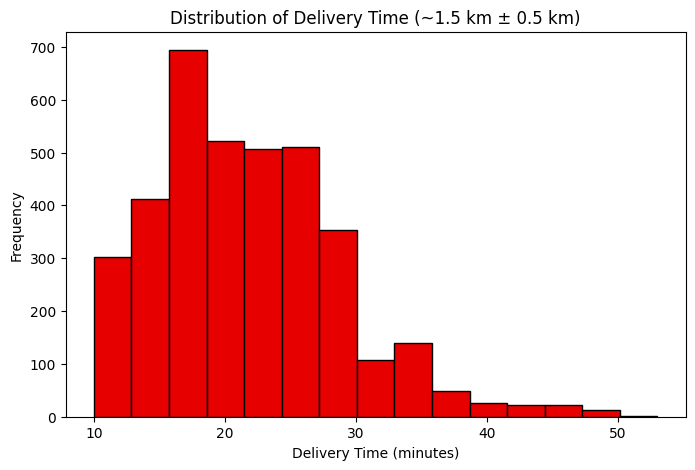


Summary Statistics (Delivery Time)
count    3677.000000
mean       21.691868
std         7.149003
min        10.000000
25%        16.000000
50%        21.000000
75%        26.000000
max        53.000000
Insight: Right-skew likely (long delays present)

Mean Delivery Time by Traffic Density
road_traffic_density  mean_time  median_time  count
                High  27.610262         28.0    916
                 Low  19.728359         19.0   2761


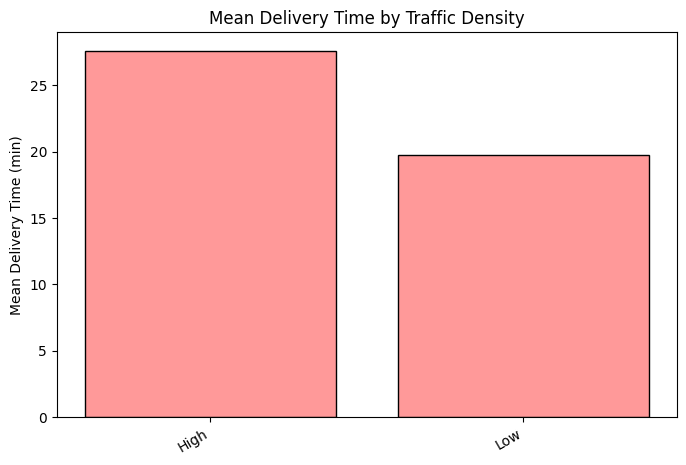


Mean Delivery Time by Weather
weather_conditions  mean_time  median_time  count
             Windy  23.392361         24.0    576
            Stormy  23.242284         24.0    648
        Sandstorms  22.734597         23.0    633
            Cloudy  21.034258         19.0    613
               Fog  20.432343         19.0    606
             Sunny  19.232945         18.0    601


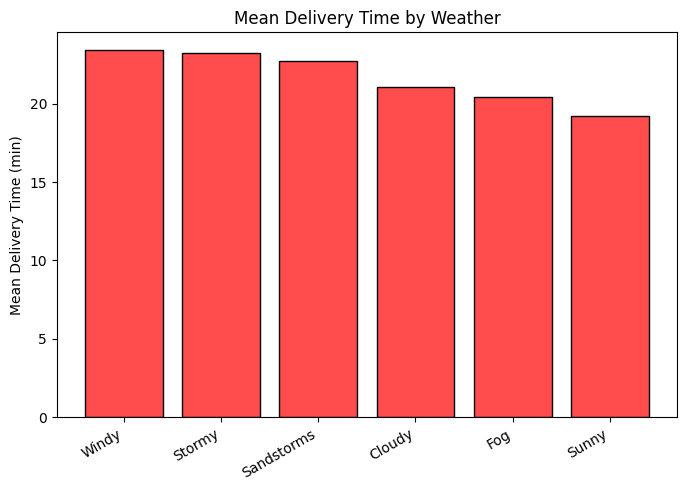


Mean Delivery Time by City
         city  mean_time  median_time  count
   Semi-Urban  47.500000         47.5      2
Metropolitian  22.671012         22.0   2608
        Urban  19.250234         18.0   1067


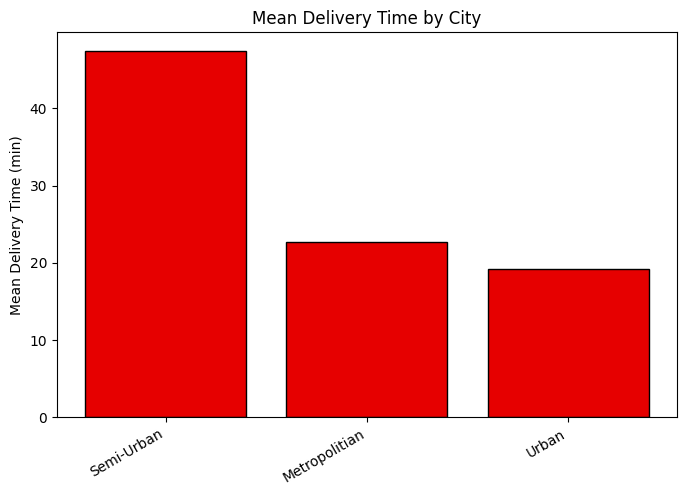


Mean Delivery Time by Festival
festival  mean_time  median_time  count
     Yes  44.833333         44.5     18
      No  21.578027         21.0   3659


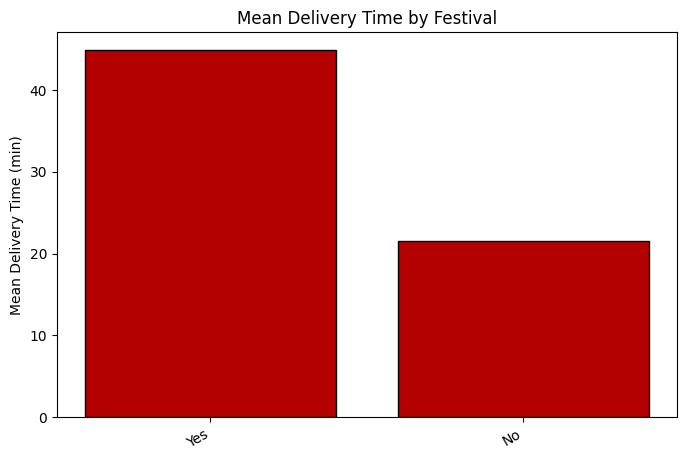

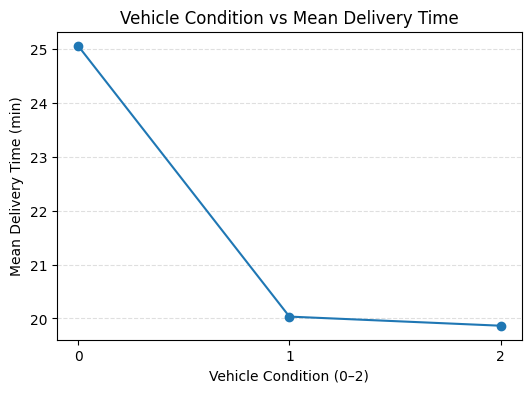

/tmp/ipython-input-3322833194.py:176: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=order, patch_artist=True, medianprops={'color':'black'})


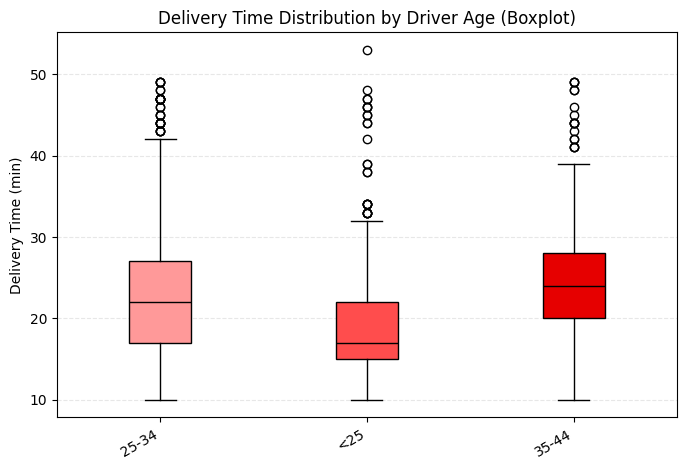

/tmp/ipython-input-3322833194.py:176: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=order, patch_artist=True, medianprops={'color':'black'})


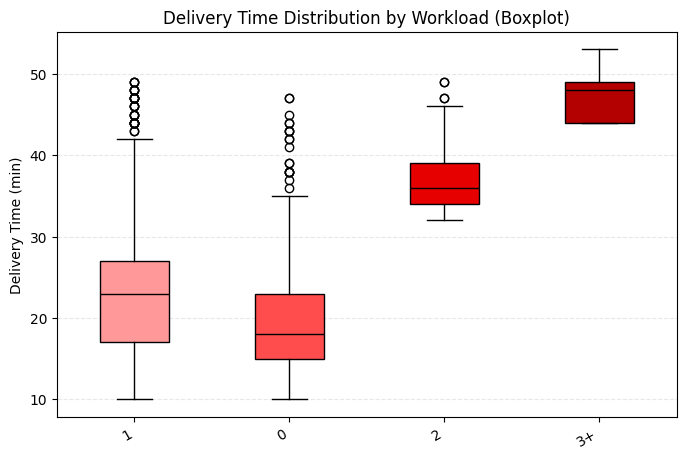

/tmp/ipython-input-3322833194.py:176: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=order, patch_artist=True, medianprops={'color':'black'})


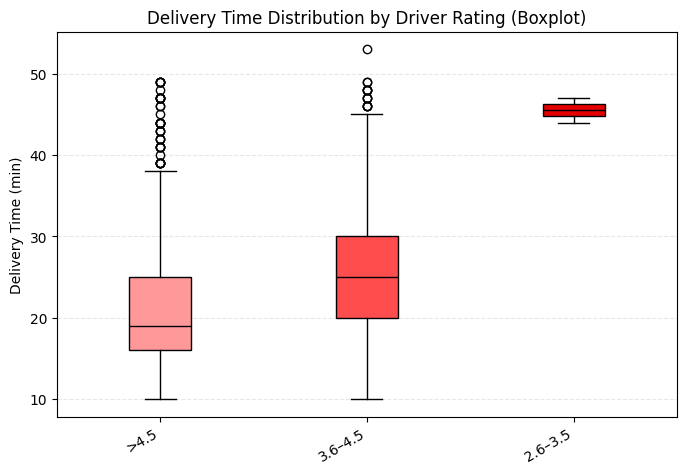


Correlation Matrix (numeric)
                         delivery_person_age  delivery_person_ratings  vehicle_condition  multiple_deliveries  distance_km  time_taken__min_
delivery_person_age                 1.000000                -0.030412           0.006433             0.138837     0.013047          0.357626
delivery_person_ratings            -0.030412                 1.000000           0.349674            -0.102406    -0.019533         -0.314523
vehicle_condition                   0.006433                 0.349674           1.000000            -0.096194    -0.014556         -0.298687
multiple_deliveries                 0.138837                -0.102406          -0.096194             1.000000    -0.033919          0.328404
distance_km                         0.013047                -0.019533          -0.014556            -0.033919     1.000000         -0.020427
time_taken__min_                    0.357626                -0.314523          -0.298687             0.328404    -0.020427  

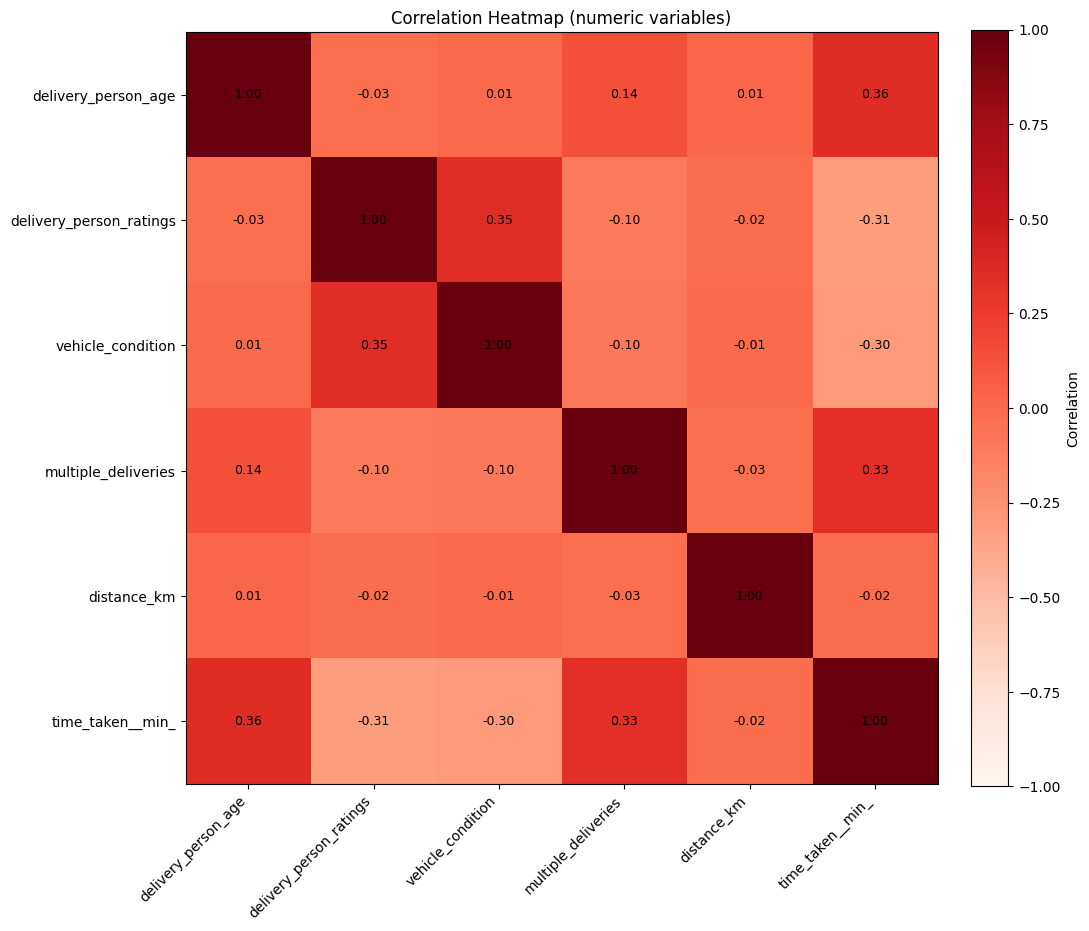


Interaction: Traffic × Weather (mean time) — NaN = no records for that combo
weather_conditions       Cloudy        Fog  Sandstorms     Stormy      Sunny      Windy
road_traffic_density                                                                   
High                  29.368750  28.892086   27.797386  27.466667  23.280822  28.705882
Low                   18.090508  17.914347   21.120833  21.799172  17.934066  21.470449


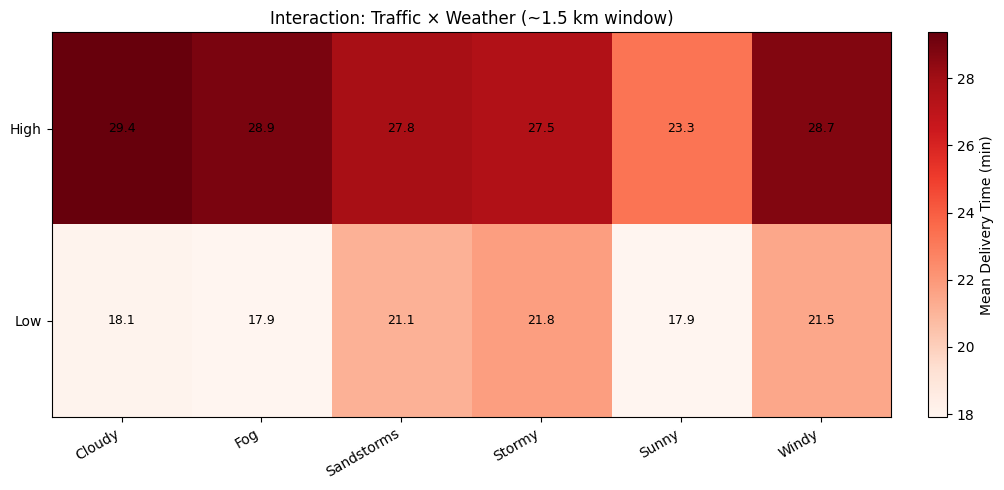


Interaction: Traffic × Workload (mean time) — NaN = no records for that combo
multi_bin                     0          1          2         3+
road_traffic_density                                            
High                  23.988189  28.208469  37.731707  47.285714
Low                   18.108108  20.802304  33.500000        NaN


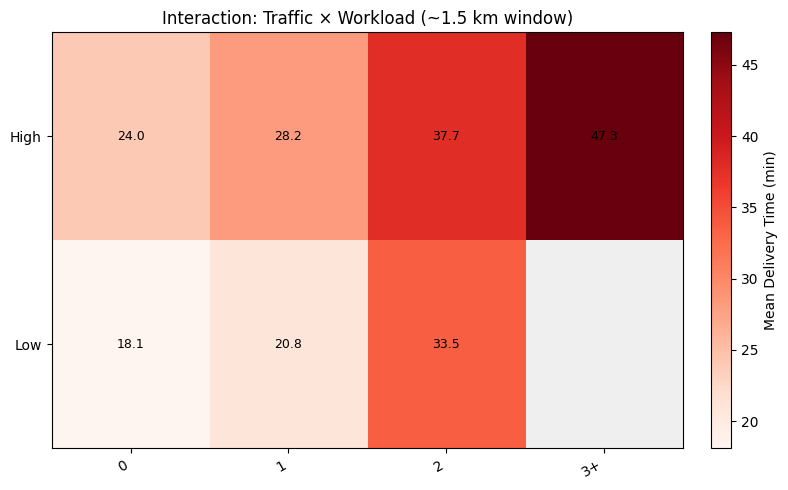


Interaction: Workload × Driver Rating (mean time) — NaN = no records for that combo
driver_rating_bin  2.6–3.5    3.6–4.5       >4.5
multi_bin                                       
0                      NaN  22.494585  18.364305
1                     45.5  25.891938  21.714541
2                      NaN  37.055556  37.880000
3+                     NaN  48.333333  46.500000


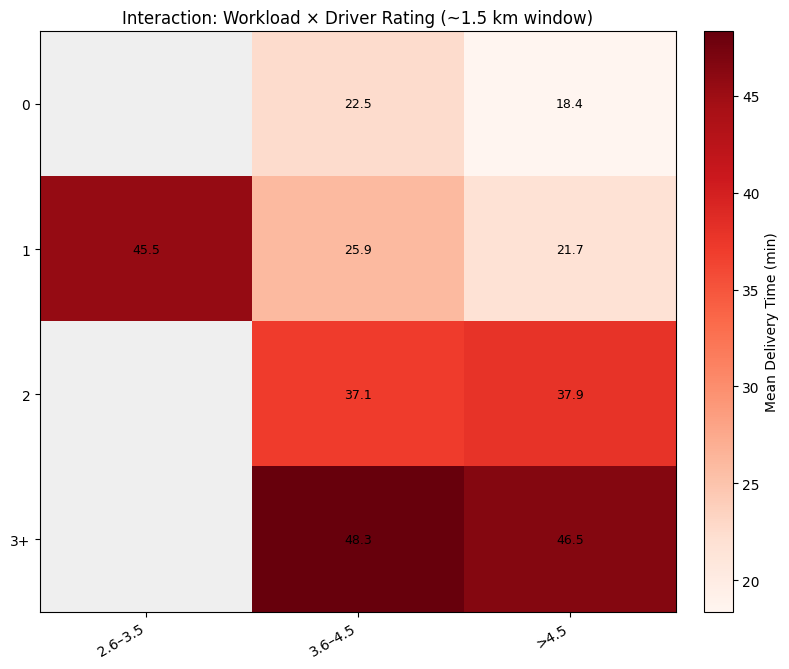


Interaction: Vehicle Condition × Weather (mean time) — NaN = no records for that combo
weather_conditions     Cloudy        Fog  Sandstorms     Stormy      Sunny      Windy
vehicle_condition                                                                    
0                   23.094787  22.761682   26.528037  27.181818  23.072115  27.919786
1                   19.967914  19.128713   20.431818  21.671362  17.293532  21.601010
2                   19.939535  19.194737   21.201005  20.767442  17.104167  20.816754


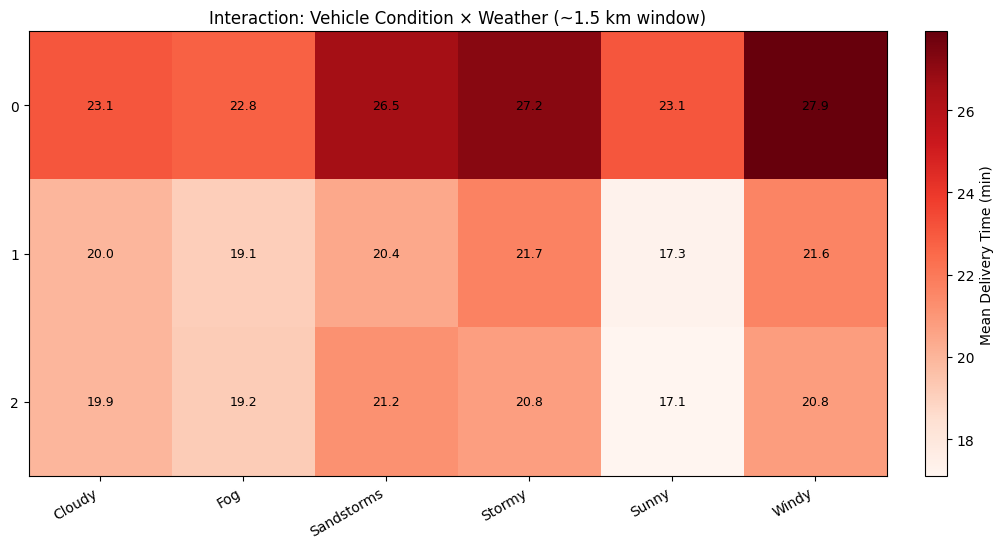

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    base = df_dropna.copy()
except NameError:
    raise NameError("df_dropna is not defined. Run your cleaning cell first.")

# Normalize column names
base.columns = (
    base.columns
    .str.strip()
    .str.replace(r"\s+", "_", regex=True)
    .str.replace(r"[()]", "_", regex=True)
    .str.lower()
)

# Detect time column robustly
def detect_time_col(cols):
    cand = [c for c in cols if "time" in c and "min" in c]
    if not cand:
        cand = [c for c in cols if "time" in c]
    cand = sorted(cand, key=lambda x: (0 if "time_taken" in x else 1, len(x)))
    return cand[0] if cand else None

time_col = detect_time_col(base.columns)
if time_col is None:
    raise KeyError("Could not detect the delivery time column (e.g., 'Time_taken (min)').")

# Force numerics
num_force = [
    'delivery_person_age','delivery_person_ratings','vehicle_condition',
    'multiple_deliveries', time_col,
    'restaurant_latitude','restaurant_longitude',
    'delivery_location_latitude','delivery_location_longitude',
    'distance_km'
]
for c in num_force:
    if c in base.columns:
        base[c] = pd.to_numeric(base[c], errors='coerce')

# Compute distance if missing
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return R * (2*np.arcsin(np.sqrt(a)))

if 'distance_km' not in base.columns:
    req = ['restaurant_latitude','restaurant_longitude','delivery_location_latitude','delivery_location_longitude']
    if not set(req).issubset(base.columns):
        raise KeyError("Missing coordinate columns to compute distance_km.")
    base['distance_km'] = haversine(
        base['restaurant_latitude'], base['restaurant_longitude'],
        base['delivery_location_latitude'], base['delivery_location_longitude']
    )

# Filter unrealistic distances
base = base[base['distance_km'] <= 50].copy()

# ---------- DistanceCategory ala Power BI (1-2, 2-3, dst) ----------
base["DistanceCategory"] = pd.cut(
    base["distance_km"],
    bins=range(1, 52),                   # 1–2, 2–3, ..., 50–51 km
    labels=[f"{i}-{i+1} km" for i in range(1, 51)],
    right=False                           # kiri inklusif, kanan eksklusif
)

# ---------- 1) Select distance window ----------
target_distance = 1.5
win = 0.5
lo, hi = target_distance - win, target_distance + win
same = base[(base['distance_km'] >= lo) & (base['distance_km'] <= hi)].copy()
print(f"Target distance ≈ {target_distance} km | Window: [{lo:.1f}, {hi:.1f}] km")
print(f"Rows in window: {same.shape[0]} ({100*same.shape[0]/max(1,len(base)):.2f}% of filtered data)")

# ---------- 1.1) Categorical cleaning & feature bins ----------
def clean_categories(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip().replace({'nan':'Unknown'}).fillna('Unknown')
    return df

same = clean_categories(same, ['road_traffic_density','weather_conditions','festival','type_of_vehicle','city','type_of_order'])

# Workload bin
if 'multiple_deliveries' in same.columns:
    same['multi_bin'] = pd.cut(same['multiple_deliveries'], bins=[-1,0,1,2,99], labels=['0','1','2','3+'])
    same['multi_bin'] = same['multi_bin'].astype(str).replace({'nan':'Unknown'})
else:
    same['multi_bin'] = 'Unknown'

# Driver age bin
if 'delivery_person_age' in same.columns:
    same['driver_age_group'] = pd.cut(
        same['delivery_person_age'], bins=[0,25,35,45,200], labels=['<25','25-34','35-44','45+']
    ).astype(str).replace({'nan':'Unknown'}).fillna('Unknown')
else:
    same['driver_age_group'] = 'Unknown'

# Driver rating bin
if 'delivery_person_ratings' in same.columns:
    same['driver_rating_bin'] = pd.cut(
        same['delivery_person_ratings'], bins=[-0.1,2.5,3.5,4.5,5.1], labels=['≤2.5','2.6–3.5','3.6–4.5','>4.5']
    ).astype(str).replace({'nan':'Unknown'}).fillna('Unknown')
else:
    same['driver_rating_bin'] = 'Unknown'

# vehicle_condition: KEEP numeric (no bin)

# ---------- Palette ----------
reds = ['#ff9999', '#ff4d4d', '#e60000', '#b30000']

# ---------- 2) Delivery time: HISTOGRAM ----------
plt.figure(figsize=(8,5))
plt.hist(same[time_col].dropna(), bins=15, color=reds[2], edgecolor='black')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Delivery Time (~{target_distance:.1f} km ± {win} km)')
plt.show()

# ---------- 3) Summary stats ----------
stats = same[time_col].describe()
print("\nSummary Statistics (Delivery Time)")
print(stats.to_string())
if not np.isnan(stats.get('mean', np.nan)) and not np.isnan(stats.get('50%', np.nan)):
    print("Insight:", "Right-skew likely (long delays present)" if stats['mean'] > stats['50%'] else "Not obviously right-skewed")

# ---------- 4) Category impact: BAR CHARTS ----------
def mean_table_and_bar(df_in, cat_col, title, color):
    if cat_col not in df_in.columns:
        print(f"[Skip] {cat_col} not found."); return pd.DataFrame()
    tbl = (
        df_in.groupby(cat_col, dropna=False)[time_col]
        .agg(mean_time='mean', median_time='median', count='count')
        .sort_values('mean_time', ascending=False)
        .reset_index()
    )
    print(f"\n{title}")
    print(tbl.to_string(index=False))
    plt.figure(figsize=(8,5))
    plt.bar(tbl[cat_col].astype(str), tbl['mean_time'], color=color, edgecolor='black')
    plt.ylabel('Mean Delivery Time (min)'); plt.title(title)
    plt.xticks(rotation=30, ha='right'); plt.show()
    return tbl

traffic_tbl = mean_table_and_bar(same, 'road_traffic_density', 'Mean Delivery Time by Traffic Density', reds[0])
weather_tbl = mean_table_and_bar(same, 'weather_conditions',   'Mean Delivery Time by Weather',         reds[1])
city_tbl    = mean_table_and_bar(same, 'city',                  'Mean Delivery Time by City',            reds[2])
fest_tbl    = mean_table_and_bar(same, 'festival',              'Mean Delivery Time by Festival',        reds[3])

# ---------- 5) Numeric relationship: LINE CHART (vehicle_condition) ----------
if 'vehicle_condition' in same.columns:
    vc_mean = same.groupby('vehicle_condition')[time_col].mean().sort_index()

    plt.figure(figsize=(6,4))
    plt.plot(vc_mean.index.astype(int), vc_mean.values, marker='o')
    plt.xlabel('Vehicle Condition (0–2)')
    plt.ylabel('Mean Delivery Time (min)')
    plt.title('Vehicle Condition vs Mean Delivery Time')
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    plt.xticks([0, 1, 2])
    plt.xlim(-0.1, 2.1)
    plt.show()

# ---------- 6) Spread per category: BOXPLOTS ----------
def boxplot_by_category(df_in, cat_col, title):
    if cat_col not in df_in.columns:
        print(f"[Skip] {cat_col} for boxplot."); return
    order = df_in[cat_col].astype(str).value_counts().index.tolist()
    data = [df_in.loc[df_in[cat_col].astype(str)==k, time_col].dropna().values for k in order]
    plt.figure(figsize=(8,5))
    bp = plt.boxplot(data, labels=order, patch_artist=True, medianprops={'color':'black'})
    for i, box in enumerate(bp['boxes']):
        box.set(facecolor=reds[min(i % len(reds), len(reds)-1)], edgecolor='black')
    plt.ylabel('Delivery Time (min)'); plt.title(title)
    plt.xticks(rotation=30, ha='right'); plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.show()

boxplot_by_category(same, 'driver_age_group',   'Delivery Time Distribution by Driver Age (Boxplot)')
boxplot_by_category(same, 'multi_bin',            'Delivery Time Distribution by Workload (Boxplot)')
boxplot_by_category(same, 'driver_rating_bin',      'Delivery Time Distribution by Driver Rating (Boxplot)')

# ---------- 7) Correlation HEATMAP ----------
num_candidates = ['delivery_person_age','delivery_person_ratings','vehicle_condition',
                  'multiple_deliveries','distance_km', time_col]
num_cols = [c for c in num_candidates if c in same.columns]
if len(num_cols) >= 2:
    corr = same[num_cols].corr()
    print("\nCorrelation Matrix (numeric)"); print(corr.to_string())
    plt.figure(figsize=(1.5*len(num_cols)+2, 1.5*len(num_cols)+2))
    data = corr.values
    im = plt.imshow(data, cmap='Reds', vmin=-1, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04, label='Correlation')
    plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha='right')
    plt.yticks(range(len(num_cols)), num_cols)
    for i in range(len(num_cols)):
        for j in range(len(num_cols)):
            plt.text(j, i, f"{data[i,j]:.2f}", ha='center', va='center', fontsize=9)
    plt.title('Correlation Heatmap (numeric variables)'); plt.tight_layout(); plt.show()
else:
    print("\nCorrelation Heatmap skipped (not enough numeric columns).")

# ---------- 8) Interaction HEATMAPS ----------
def heatmap_from_pivot(pivot_df, title):
    if pivot_df.empty:
        print(f"[Skip] {title} (no data)."); return
    arr = pivot_df.values.astype(float)
    arr_masked = np.ma.masked_invalid(arr)
    cmap = plt.cm.Reds.copy(); cmap.set_bad(color='#efefef')
    plt.figure(figsize=(max(8, 1.2*pivot_df.shape[1]+3), max(5, 1.2*pivot_df.shape[0]+2)))
    im = plt.imshow(arr_masked, aspect='auto', cmap=cmap)
    plt.colorbar(im, fraction=0.046, pad=0.04, label='Mean Delivery Time (min)')
    plt.xticks(range(pivot_df.shape[1]), pivot_df.columns, rotation=30, ha='right')
    plt.yticks(range(pivot_df.shape[0]), pivot_df.index)
    for i in range(pivot_df.shape[0]):
        for j in range(pivot_df.shape[1]):
            val = pivot_df.values[i, j]
            if not np.isnan(val):
                plt.text(j, i, f"{val:.1f}", ha='center', va='center', fontsize=9)
    plt.title(title); plt.tight_layout(); plt.show()

pairs = [
    ('road_traffic_density','weather_conditions', 'Interaction: Traffic × Weather'),
    ('road_traffic_density','multi_bin',          'Interaction: Traffic × Workload'),
    ('multi_bin','driver_rating_bin',             'Interaction: Workload × Driver Rating'),
    ('vehicle_condition','weather_conditions',     'Interaction: Vehicle Condition × Weather'),
]
for r, c, title in pairs:
    if {r, c}.issubset(same.columns):
        pivot = same.pivot_table(index=r, columns=c, values=time_col, aggfunc='mean')
        print(f"\n{title} (mean time) — NaN = no records for that combo")
        print(pivot.to_string())
        heatmap_from_pivot(pivot, f"{title} (~{target_distance:.1f} km window)")
    else:
        print(f"[Skip] {title} — missing columns.")


In [ ]:
import pandas as pd
import numpy as np

try:
    df_filtered = df_dropna.copy()
except NameError:
    raise NameError("df_dropna is not defined. Jalankan cleaning cell dulu.")

if "Delivery_person_Age" in df_filtered.columns:
    df_filtered["driver_age_group"] = pd.cut(
        df_filtered["Delivery_person_Age"],
        bins=[0, 25, 35, 45, 200],
        labels=["<25", "25-34", "35-44", "45+"]
    ).astype(str).replace({"nan": "Unknown"}).fillna("Unknown")
else:
    df_filtered["driver_age_group"] = "Unknown"

# --- Driver Rating bin ---
if "Delivery_person_Ratings" in df_filtered.columns:
    df_filtered["driver_rating_bin"] = pd.cut(
        df_filtered["Delivery_person_Ratings"],
        bins=[-0.1, 2.5, 3.5, 4.5, 5.1],
        labels=["≤2.5", "2.6–3.5", "3.6–4.5", ">4.5"]
    ).astype(str).replace({"nan": "Unknown"}).fillna("Unknown")
else:
    df_filtered["driver_rating_bin"] = "Unknown"


df_filtered = df_filtered[df_filtered["distance_km"] < 50].copy()


df_filtered["DistanceCategory"] = pd.cut(
    df_filtered["distance_km"],
    bins=range(1, 52),
    labels=[f"{str(i).zfill(2)}-{str(i+1).zfill(2)} km" for i in range(1, 51)],
    right=False
)

df_filtered = df_filtered.sort_values(by="distance_km", ascending=True)

df_filtered.to_csv("Zomato_Final_Dataset.csv", index=False)
print("File saved")


File saved


In [ ]:
df_filtered.to_csv("Zomato_Final_Dataset.csv", index=False, sep=",", encoding="utf-8-sig", quotechar='"')